# Train scratch encoder–decoder (BriefMe `arg_summ`)

This notebook calls **`briefme.train_scratch_loop.run_scratch_training`** — the same logic as [`scripts/train_scratch_seq2seq.py`](../scripts/train_scratch_seq2seq.py).

**Recommended order:** (1) setup → **(2) sanity** (small Hub sample) → **(3) sanity plots** → **(4) full Hub data** → **(5) train tiny** → **(6) train medium** (same full Hub rows; long wall times — prefer CLI/`tmux` for unattended runs).

Keep **data loading** (Hub stream + tokenizer + `scratch_dataloaders_from_examples`) in **one code cell** and **training** (`run_scratch_training` only) in the **next**. Each cell prints its own **wall time** so you can see Hub/IO vs GPU/compute separately. **`logging_steps`** / **`eval_steps`** in `ScratchTrainConfig` add train snapshots and dev evals on a **global-step** timeline (see `history.json` and `plot_scratch_history`).

**Setup:** `pip install -e ".[dev]"`, **Python (cs474)** kernel, **`HUGGINGFACE_HUB_TOKEN`** in `.env`. Loss plots need **finite** `train_loss` / `dev_loss` — if you ever saw NaN with the T5 tokenizer, restart the kernel and rerun from setup so you pick up the decoder padding fix in `transformer/model.py`.

Long unattended jobs: use the CLI + `tmux`/`screen` rather than relying on this kernel staying alive.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

from dotenv import load_dotenv
import matplotlib.pyplot as plt


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "briefme").is_dir():
        return cwd
    if (cwd.parent / "src" / "briefme").is_dir():
        return cwd.parent
    return cwd


REPO_ROOT = _repo_root()
SRC_ROOT = REPO_ROOT / "src"

try:
    import briefme as _briefme_check  # noqa: F401
except ImportError:
    if SRC_ROOT.is_dir():
        sys.path.insert(0, str(SRC_ROOT))

load_dotenv(REPO_ROOT / ".env", override=True)

def plot_scratch_history(history: list[dict], title: str = "Scratch seq2seq") -> None:
    """Plot loss + dev metrics from `run_scratch_training` history.

    Supports legacy epoch-only rows and step-granular history (``train_log`` + ``eval`` rows).
    """
    if not history:
        print("No history rows to plot.")
        return

    eval_rows = [r for r in history if r.get("dev_loss") is not None]
    train_logs = [r for r in history if r.get("kind") == "train_log"]
    if not eval_rows:
        print("No eval rows (with dev_loss) in history.")
        return

    use_step_x = all("global_step" in r for r in eval_rows)
    if use_step_x:
        x_eval = [r["global_step"] for r in eval_rows]
        x_label = "global step"
    else:
        x_eval = [r["epoch"] for r in eval_rows]
        x_label = "epoch"

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    ax0, ax1, ax2 = axes

    if train_logs:
        ax0.plot(
            [r["global_step"] for r in train_logs],
            [r["train_loss"] for r in train_logs],
            ".-",
            alpha=0.65,
            markersize=4,
            label="train loss (logging_steps)",
        )
    ax0.plot(x_eval, [r["train_loss"] for r in eval_rows], "o-", label="train loss @ eval")
    ax0.plot(x_eval, [r["dev_loss"] for r in eval_rows], "s-", label="dev loss @ eval")
    ax0.set_xlabel(x_label)
    ax0.set_ylabel("cross-entropy loss")
    ax0.set_title("Loss (teacher forcing)")
    ax0.legend(fontsize=8)
    ax0.grid(True, alpha=0.3)

    ax1.plot(x_eval, [r["dev_rougeL_f"] for r in eval_rows], "o-", label="ROUGE-L F-score")
    ax1.plot(x_eval, [r["dev_token_f1_macro"] for r in eval_rows], "s-", label="token overlap F1 (macro)")
    ax1.set_xlabel(x_label)
    ax1.set_ylabel("0–1")
    ax1.set_title("Dev match quality (greedy decode)")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    dev_times = [r.get("dev_ce_and_greedy_seconds") for r in eval_rows]
    if all(t is not None for t in dev_times):
        ax2.plot(x_eval, dev_times, "o-", color="steelblue")
        ax2.set_xlabel(x_label)
        ax2.set_ylabel("seconds")
        ax2.set_title("Dev eval wall time (CE + greedy)")
        ax2.grid(True, alpha=0.3)
    elif not use_step_x and all(r.get("epoch_seconds") is not None for r in eval_rows):
        ax2.bar([str(r["epoch"]) for r in eval_rows], [r["epoch_seconds"] for r in eval_rows], color="steelblue")
        ax2.set_xlabel("epoch")
        ax2.set_ylabel("seconds")
        ax2.set_title("Wall time per epoch")
    else:
        ax2.text(0.5, 0.5, "No timing fields in eval rows", ha="center", va="center")
        ax2.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /Users/naataaniitsosie/repos/cs474


### Sanity check (run this first)

**Two code cells:** (A) **Data** — load tokenizer, materialize from Hub, build `sanity_train_loader` / `sanity_dev_loader`; prints **`[sanity — data pipeline] wall time`**. (B) **Train** — `run_scratch_training` only; prints **`[sanity — training] wall time`**. Re-run (B) without re-streaming from the Hub.

Uses **~64 train / ~32 dev** examples and **1–2 epochs**. Tune `SANITY_*` below if you want a longer smoke pass.

Below, **Full Hub splits** materializes once, then trains **tiny** then **medium** on that materialization.


In [3]:
import time
from pathlib import Path

from briefme.seq2seq_data import DEFAULT_T5_TASK_PREFIX, default_train_dev_materialize, get_t5_tokenizer
from briefme.train_scratch_loop import ScratchTrainConfig, scratch_dataloaders_from_examples
from transformer.config import HF_T5_BASELINE_MODEL_ID

# --- tweak for a slightly longer smoke test ---
SANITY_TRAIN_LIMIT = 64
SANITY_DEV_LIMIT = 32
SANITY_EPOCHS = 2
SANITY_BATCH = 4

SANITY_CFG = ScratchTrainConfig(
    preset="tiny",
    epochs=SANITY_EPOCHS,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=1.0,
    device="auto",
    output_dir=REPO_ROOT / "runs" / "notebook_scratch_sanity",
    source_prefix=DEFAULT_T5_TASK_PREFIX,
    max_new_tokens_eval=min(64, 128),
    logging_steps=4,
    eval_steps=8,
)

_t_data0 = time.perf_counter()
print("[briefme] loading tokenizer...", flush=True)
tokenizer = get_t5_tokenizer(HF_T5_BASELINE_MODEL_ID)
train_ex, dev_ex = default_train_dev_materialize(SANITY_TRAIN_LIMIT, SANITY_DEV_LIMIT)
sanity_train_loader, sanity_dev_loader = scratch_dataloaders_from_examples(
    train_ex,
    dev_ex,
    tokenizer,
    preset="tiny",
    source_prefix=DEFAULT_T5_TASK_PREFIX,
    batch_size=SANITY_BATCH,
)
print(f"[sanity — data pipeline] wall time: {time.perf_counter() - _t_data0:.2f}s", flush=True)

[briefme] loading tokenizer...


[briefme] streaming 'train' from Hub (limit=64)...
[briefme]   'train': done (64 rows)
[briefme] streaming 'dev' from Hub (limit=32)...
[briefme]   'dev': done (32 rows)


[sanity — data pipeline] wall time: 90.96s


In [6]:
import time

from briefme.train_scratch_loop import run_scratch_training

_t_train0 = time.perf_counter()
sanity_history = run_scratch_training(
    SANITY_CFG,
    tokenizer=tokenizer,
    train_loader=sanity_train_loader,
    dev_loader=sanity_dev_loader,
)
print(f"[sanity — training] wall time: {time.perf_counter() - _t_train0:.2f}s", flush=True)
sanity_history[-1]

[briefme] scratch seq2seq training...


{
  "kind": "eval",
  "global_step": 8,
  "epoch": 1,
  "train_loss": 10.496143698692322,
  "dev_loss": 10.522385716438293,
  "dev_rougeL_f": 0.0031658026113671276,
  "dev_token_f1_macro": 0.001059322033898305,
  "n_train": 64,
  "n_dev": 32,
  "train_seconds": 0.864,
  "dev_ce_and_greedy_seconds": 5.714,
  "epoch_seconds": 6.578
}
[step 8 · epoch 1/2] eval wall 5.7s (train seg 0.9s)
{
  "kind": "eval",
  "global_step": 16,
  "epoch": 1,
  "train_loss": 10.476626753807068,
  "dev_loss": 10.476773738861084,
  "dev_rougeL_f": 0.003040970741530443,
  "dev_token_f1_macro": 0.0,
  "n_train": 64,
  "n_dev": 32,
  "train_seconds": 0.394,
  "dev_ce_and_greedy_seconds": 5.176,
  "epoch_seconds": 12.201
}
[step 16 · epoch 1/2] eval wall 5.2s (train seg 0.4s)
{
  "kind": "eval",
  "global_step": 24,
  "epoch": 2,
  "train_loss": 10.264716148376465,
  "dev_loss": 10.421891808509827,
  "dev_rougeL_f": 0.005771503400813746,
  "dev_token_f1_macro": 0.0019651191353475803,
  "n_train": 64,
  "n_dev": 3

{'kind': 'eval',
 'global_step': 32,
 'epoch': 2,
 'train_loss': 10.125948667526245,
 'dev_loss': 10.349904537200928,
 'dev_rougeL_f': 0.006273383570707168,
 'dev_token_f1_macro': 0.004404102253678524,
 'n_train': 64,
 'n_dev': 32,
 'train_seconds': 0.464,
 'dev_ce_and_greedy_seconds': 5.107,
 'epoch_seconds': 11.204}

### Learning curves (sanity run)

- **X-axis:** **global step** when `logging_steps` / `eval_steps` are set (finer curves); otherwise **epoch** for legacy runs.
- **Left:** train vs dev CE — dotted **logging_steps** train snapshots plus **eval** points (train segment loss since last eval vs dev).
- **Middle:** **ROUGE-L F** vs **token F1** on **greedy** dev decode (same interpretation as before).
- **Right:** **`dev_ce_and_greedy_seconds`** per eval (step-granular runs) or **`epoch_seconds`** bars for old epoch-only history.

Uses `sanity_history`; for full-Hub runs use `tiny_history` / `medium_history` or load each run's `history.json`.


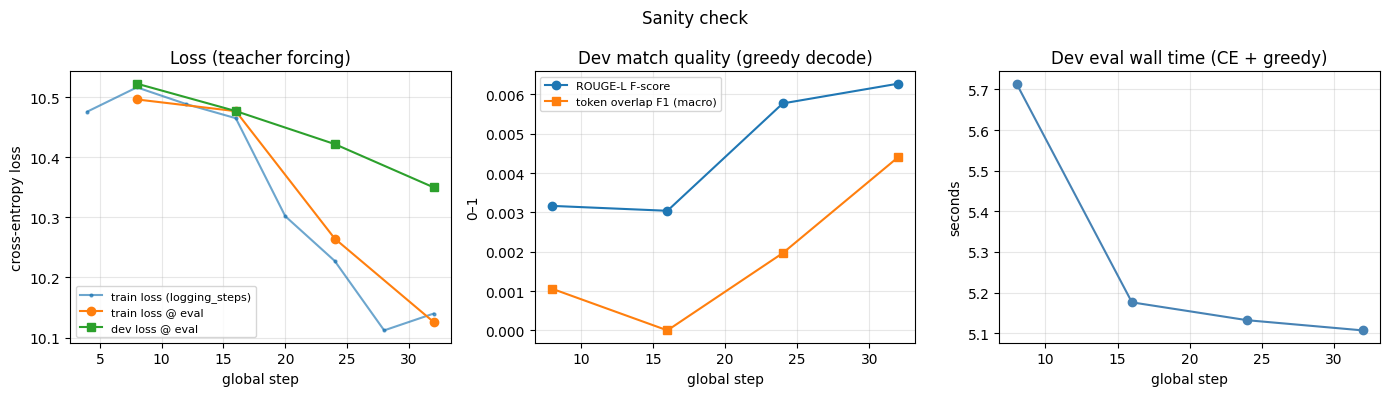

In [7]:
import json

plot_scratch_history(sanity_history, title="Sanity check")

# Optional: reload a past run without retraining
# hist_path = REPO_ROOT / "runs" / "notebook_scratch_sanity" / "history.json"
# plot_scratch_history(json.loads(hist_path.read_text()), title="From history.json")

### How teams track evaluations during training (quick overview)

| Practice | What it gives you |
|----------|-------------------|
| **Experiment trackers** (Weights & Biases, MLflow, Neptune, TensorBoard) | One dashboard for **loss curves**, **hyperparameters**, **system metrics**, **artifact checkpoints**, and **side-by-side runs**. |
| **Structured logs** | JSON/CSV lines per epoch or step → grep, SQL, or notebooks; pairs with Git commit hash + config dump for **reproducibility**. |
| **Checkpoint policy** | Save `best` by **dev loss** or **dev ROUGE** (your loop uses **best dev loss**); keep **config + tokenizer id** next to weights. |
| **Offline eval cadence** | Heavy **generation + `aggregate()`** less often than loss (expensive); lightweight **loss every epoch**, full decode **every N epochs** or at end. |
| **Golden dev subset** | Fixed **small batch of examples** logged as **preview strings** each checkpoint to spot **mode collapse** early. |
| **CI / regression** | Tiny config **smoke train** on CPU in CI (like your sanity cell) before merging training code changes. |

This repo stays lightweight: **`history.json`** + plots here; for a larger team project you’d add **W&B / MLflow** with ~10 lines of integration in the training loop.

### Full Hub splits — tiny then medium presets

After sanity, these cells **materialize the full Hub train/dev splits once**, build **tiny** loaders, train, then **medium** loaders from the **same** row lists (re-tokenized with larger max lengths), train again.

**Curves:** **`logging_steps`** with **`eval_steps=None`** (once-per-epoch dev eval). For runs longer than ~30 minutes, prefer **`scripts/train_scratch_seq2seq.py`** + **`tmux`**/`screen` instead of this kernel.


In [8]:
from pathlib import Path

from briefme.seq2seq_data import DEFAULT_T5_TASK_PREFIX
from briefme.train_scratch_loop import ScratchTrainConfig

TINY_CFG = ScratchTrainConfig(
    preset="tiny",
    epochs=3,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=1.0,
    device="auto",
    output_dir=REPO_ROOT / "runs" / "notebook_scratch_tiny_full",
    source_prefix=DEFAULT_T5_TASK_PREFIX,
    max_new_tokens_eval=128,
    logging_steps=100,
    eval_steps=None,
)

MEDIUM_CFG = ScratchTrainConfig(
    preset="medium",
    epochs=3,
    lr=3e-4,
    weight_decay=0.01,
    grad_clip=1.0,
    device="auto",
    output_dir=REPO_ROOT / "runs" / "notebook_scratch_medium_full",
    source_prefix=DEFAULT_T5_TASK_PREFIX,
    max_new_tokens_eval=128,
    logging_steps=100,
    eval_steps=None,
)

TINY_BATCH = 8
MEDIUM_BATCH = 4  # lower if the medium preset hits CUDA OOM


In [9]:
import time

from briefme.seq2seq_data import default_train_dev_materialize, get_t5_tokenizer
from briefme.train_scratch_loop import scratch_dataloaders_from_examples
from transformer.config import HF_T5_BASELINE_MODEL_ID

_t_full_data0 = time.perf_counter()
print("[briefme] loading tokenizer...", flush=True)
tokenizer_full = get_t5_tokenizer(HF_T5_BASELINE_MODEL_ID)
print("[briefme] streaming full train + dev splits from Hub...", flush=True)
full_train_ex, full_dev_ex = default_train_dev_materialize(None, None)

tiny_train_loader, tiny_dev_loader = scratch_dataloaders_from_examples(
    full_train_ex,
    full_dev_ex,
    tokenizer_full,
    preset=TINY_CFG.preset,
    source_prefix=TINY_CFG.source_prefix,
    batch_size=TINY_BATCH,
)
medium_train_loader, medium_dev_loader = scratch_dataloaders_from_examples(
    full_train_ex,
    full_dev_ex,
    tokenizer_full,
    preset=MEDIUM_CFG.preset,
    source_prefix=MEDIUM_CFG.source_prefix,
    batch_size=MEDIUM_BATCH,
)

print(f"[full Hub — data pipeline] wall time: {time.perf_counter() - _t_full_data0:.2f}s", flush=True)
print(f"  train rows: {len(full_train_ex)}  dev rows: {len(full_dev_ex)}", flush=True)


[briefme] streaming 'train' from Hub (limit=2048)...
[briefme]   'train': 500 rows...
[briefme]   'train': 1000 rows...
[briefme]   'train': 1500 rows...
[briefme]   'train': 2000 rows...
[briefme]   'train': done (2048 rows)
[briefme] streaming 'dev' from Hub (limit=512)...
[briefme]   'dev': 500 rows...
[briefme]   'dev': done (512 rows)


[full — data pipeline] wall time: 109.89s


[briefme] scratch seq2seq training...


{
  "kind": "eval",
  "global_step": 128,
  "epoch": 1,
  "train_loss": 8.791124641895294,
  "dev_loss": 7.2565479800105095,
  "dev_rougeL_f": 0.0,
  "dev_token_f1_macro": 0.0,
  "n_train": 2048,
  "n_dev": 512,
  "train_seconds": 9.365,
  "dev_ce_and_greedy_seconds": 44.247,
  "epoch_seconds": 53.611
}
[step 128 · epoch 1/3] eval wall 44.2s (train seg 9.4s)
{
  "kind": "eval",
  "global_step": 256,
  "epoch": 1,
  "train_loss": 7.003918658941984,
  "dev_loss": 7.0128608494997025,
  "dev_rougeL_f": 0.08351149110827814,
  "dev_token_f1_macro": 0.08679784173436815,
  "n_train": 2048,
  "n_dev": 512,
  "train_seconds": 7.304,
  "dev_ce_and_greedy_seconds": 8.056,
  "epoch_seconds": 69.028
}
[step 256 · epoch 1/3] eval wall 8.1s (train seg 7.3s)
{
  "kind": "eval",
  "global_step": 384,
  "epoch": 2,
  "train_loss": 6.613079618662596,
  "dev_loss": 6.892067924141884,
  "dev_rougeL_f": 0.08606255370967535,
  "dev_token_f1_macro": 0.08984764218084745,
  "n_train": 2048,
  "n_dev": 512,
  "tr

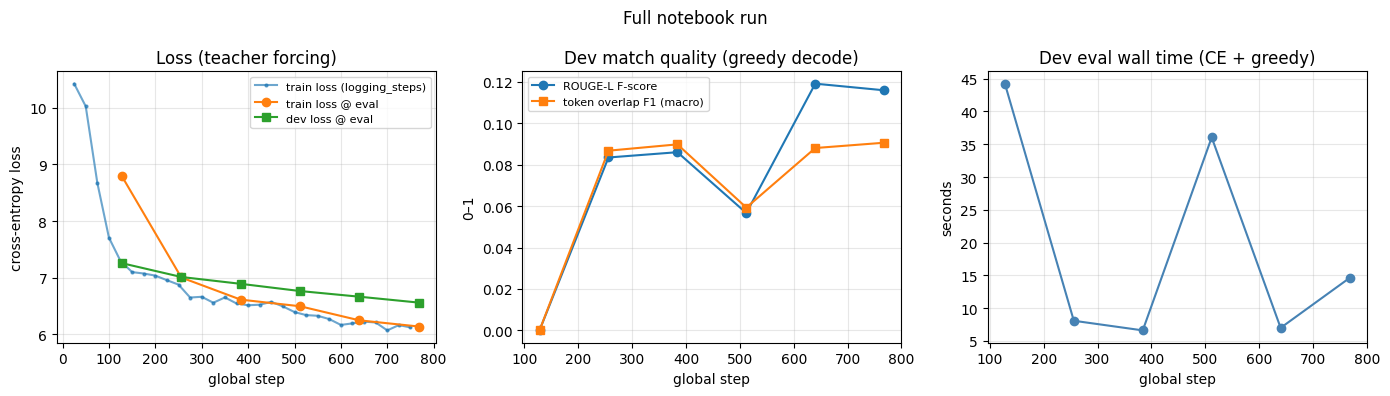

{'kind': 'eval', 'global_step': 768, 'epoch': 3, 'train_loss': 6.138544991612434, 'dev_loss': 6.560534633696079, 'dev_rougeL_f': 0.11596166729501055, 'dev_token_f1_macro': 0.09064569203541084, 'n_train': 2048, 'n_dev': 512, 'train_seconds': 7.267, 'dev_ce_and_greedy_seconds': 14.59, 'epoch_seconds': 36.698}


In [10]:
import time

from briefme.train_scratch_loop import run_scratch_training

_t_train0 = time.perf_counter()
tiny_history = run_scratch_training(
    TINY_CFG,
    tokenizer=tokenizer_full,
    train_loader=tiny_train_loader,
    dev_loader=tiny_dev_loader,
)
print(f"[tiny full — training] wall time: {time.perf_counter() - _t_train0:.2f}s", flush=True)
plot_scratch_history(tiny_history, title="Tiny preset · full Hub")
print(tiny_history[-1])


In [ ]:
import time

from briefme.train_scratch_loop import run_scratch_training

_t_train0 = time.perf_counter()
medium_history = run_scratch_training(
    MEDIUM_CFG,
    tokenizer=tokenizer_full,
    train_loader=medium_train_loader,
    dev_loader=medium_dev_loader,
)
print(f"[medium full — training] wall time: {time.perf_counter() - _t_train0:.2f}s", flush=True)
plot_scratch_history(medium_history, title="Medium preset · full Hub")
print(medium_history[-1])


**Artifacts:** each run writes **`best.pt`** (lowest dev loss so far) and **`history.json`** under that run's `output_dir` — sanity: `runs/notebook_scratch_sanity`; tiny full: `runs/notebook_scratch_tiny_full`; medium full: `runs/notebook_scratch_medium_full`.
